# Notebook 1: Transformers 101

We build a character-level language model incrementally, training on Molière's plays:

| Stage | Model | What's new |
|-------|-------|------------|
| 1 | **Bigram** | A bare embedding lookup (no memory) |
| 2 | **MLP** | Fixed-size context window via causal sliding windows |
| 3 | **Single attention head** | Dynamic, input-dependent context weighting |
| 4 | **Transformer block** | Multi-head attention + FFN + LayerNorm + residuals |
| 5 | **MiniGPT** | Stacked blocks + positional embeddings |

At each stage you can experiment with hyperparameters and see the effect on the loss curves.

## 0. Setup

In [96]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time

# ── Device selection ─────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print(f"Using device: {device}")

Using device: mps


## 1. Data: Molière's plays

In [97]:
from datasets import load_dataset

ds = load_dataset("grlll/tiny-moliere")
text = "\n".join(ds["train"]["text"])

print(f"Total characters : {len(text):,}")
print(f"\nFirst 400 characters:\n{text[:400]}")

Total characters : 2,326,764

First 400 characters:
La Jalousie du Barbouillé
Acteurs
Le Barbouillé, mari d'Angélique.
Le Docteur.
Angélique, fille de Gorgibus.
Valère, amant d'Angélique.
Cathau, suivante d'Angélique.
Gorgibus, père d'Angélique.
Villebrequin.
Scène I
Le Barbouillé
Il faut avouer que je suis le plus malheureux de tous les hommes. J'ai une femme qui me fait enrager :  au lieu
de me donner du soulagement et de faire les choses à mon s


### Character-level tokenization

We use the simplest possible vocabulary: every unique character gets an integer ID. This gives a very small vocabulary (~90 tokens).

*In Notebook 3 (Tokenization) we will explore more sophisticated methods like BPE.*

In [98]:
chars = sorted(set(text))
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size} unique characters")
print(f"Characters: {''.join(chars)!r}")

# Encoder / decoder
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}

def encode(s):  return [stoi[c] for c in s]
def decode(ids): return "".join(itos[i] for i in ids)

# Sanity check
sample = "Molière parle!"
print(f"\nencode({sample!r})\n  = {encode(sample)}")
print(f"decode(...) = {decode(encode(sample))!r}")

Vocabulary size: 91 unique characters
Characters: '\n !"\'(),.0123456789:;?ABCDEFGHIJLMNOPQRSTUVXYZ[]abcdefghijlmnopqrstuvxyz°ÇÉàâçèéêëìîïòôùûœ−'

encode('Molière parle!')
  = [33, 61, 58, 56, 78, 64, 52, 1, 62, 48, 64, 58, 52, 2]
decode(...) = 'Molière parle!'


### Train / validation split

We take 90% of the text for training and hold out 10% as a validation set.
The split happens at a single index with no shuffling, to preserve text continuity.

In [99]:
torch.manual_seed(42)
data = torch.tensor(encode(text), dtype=torch.long)

split_idx = int(0.9 * len(data))
train_data = data[:split_idx]
val_data   = data[split_idx:]
print(f"Train tokens : {len(train_data):,}")
print(f"Val tokens   : {len(val_data):,}")

Train tokens : 2,094,087
Val tokens   : 232,677


### Visualise the character distribution

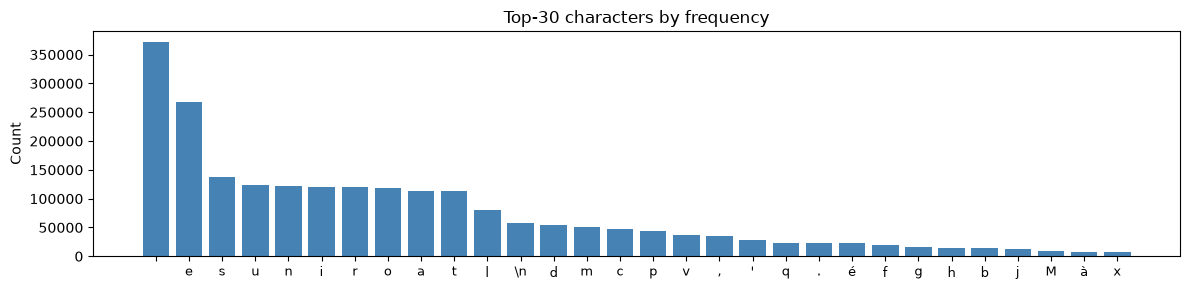

In [100]:
from collections import Counter

counts = Counter(text)
labels, freqs = zip(*sorted(counts.items(), key=lambda kv: -kv[1])[:30])

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(range(len(labels)), freqs, color="steelblue")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels([repr(c)[1:-1] for c in labels], fontsize=9)
ax.set_ylabel("Count")
ax.set_title("Top-30 characters by frequency")
plt.tight_layout()
plt.show()

### Global hyperparameters

These two values are shared by all models. Feel free to change them!

In [101]:
# ┌─────────────────────────────────────────────────────────────────────┐
# │  Global hyperparameters: used by every model in this notebook      │
# └─────────────────────────────────────────────────────────────────────┘
CONTEXT = 128   # characters of history the model can see
BATCH   = 64    # sequences processed in one gradient step

## 2. Shared utilities

In [102]:
def get_batch(split):
    """Sample a random batch of (input, target) sequences."""
    data = train_data if split == "train" else val_data
    ix   = torch.randint(len(data) - CONTEXT, (BATCH,))
    x    = torch.stack([data[i     : i + CONTEXT    ] for i in ix])
    y    = torch.stack([data[i + 1 : i + CONTEXT + 1] for i in ix])
    return x.to(device), y.to(device)

# Quick sanity check
xb, yb = get_batch("train")
print(f"Batch x: {tuple(xb.shape)}  (batch x context)")
print(f"Batch y: {tuple(yb.shape)}  (y[i] = x[i] shifted by 1)")
print(f"First input (decoded): {decode(xb[0].tolist())[:60]!r}")

Batch x: (64, 128)  (batch x context)
Batch y: (64, 128)  (y[i] = x[i] shifted by 1)
First input (decoded): ' \nLe Commissaire\nNous allons revenir.\nSganarelle\nOr çà, je v'


In [103]:
@torch.no_grad()
def generate(model, seed_text, n_chars=300, temperature=1.0, top_k=None):
    """
    Autoregressively generate n_chars characters.

    Args:
        seed_text   : string to start from
        n_chars     : number of characters to generate
        temperature : >1 = more random, <1 = more confident
        top_k       : if set, only sample from the top-k most likely tokens
    """
    model.eval()
    ids = encode(seed_text)
    for _ in range(n_chars):
        # Keep only the last CONTEXT characters
        x = torch.tensor([ids[-CONTEXT:]], dtype=torch.long, device=device)
        logits, _ = model(x)
        logits = logits[0, -1] / temperature          # (vocab_size,)
        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, vocab_size))
            logits[logits < v[-1]] = float('-inf')
        probs   = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, 1).item()
        ids.append(next_id)
    return decode(ids)

In [104]:
def train_loop(model, n_steps, lr=3e-3, eval_every=200, cosine_decay=False):
    """
    Train model for n_steps steps with AdamW.
    Returns a list of {step, train, val} dicts for plotting.
    """
    model.to(device).train()
    opt     = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-1)
    sched   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_steps, eta_min=lr/30) if cosine_decay else None
    history = []
    t0      = time.time()

    for step in range(n_steps + 1):
        # ── Evaluate ────────────────────────────────────────────────
        if step % eval_every == 0:
            model.eval()
            with torch.no_grad():
                tl = np.mean([model(*get_batch("train"))[1].item() for _ in range(5)])
                vl = np.mean([model(*get_batch("val")  )[1].item() for _ in range(5)])
            history.append({"step": step, "train": float(tl), "val": float(vl)})
            print(f"step {step:5d}/{n_steps}  |  train {tl:.3f}  val {vl:.3f}  |  {time.time()-t0:.0f}s")
            model.train()
        # ── Gradient step ───────────────────────────────────────────
        if step < n_steps:
            x, y = get_batch("train")
            _, loss = model(x, y)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            if sched: sched.step()

    return history


def plot_losses(*histories, labels=None):
    """Overlay training and validation curves for one or more models."""
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for i, h in enumerate(histories):
        label  = (labels[i] if labels else f"Model {i+1}")
        color  = colors[i % len(colors)]
        steps  = [e["step"] for e in h]
        train  = [e["train"] for e in h]
        val    = [e["val"]   for e in h]
        ax.plot(steps, train, color=color, linewidth=1.5, label=f"{label} (train)")
        ax.plot(steps, val,   color=color, linewidth=1.5, linestyle="--", label=f"{label} (val)")
    ax.set_xlabel("Step")
    ax.set_ylabel("Cross-entropy loss")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### Baseline: what is a good loss?

A model that assigns equal probability to all characters would achieve:
$$\mathcal{L}_{\text{random}} = -\log\left(\frac{1}{V}\right) = \log V$$

In [105]:
import math
random_loss = math.log(vocab_size)
print(f"Random baseline loss: {random_loss:.3f}  (= log {vocab_size})")
print(f"This is our floor: any model should beat this from the first few steps.")

Random baseline loss: 4.511  (= log 91)
This is our floor: any model should beat this from the first few steps.


---

## 3. Model 1: Bigram

**Idea**: predict the next character using *only* the previous character.

The model has a single `vocab_size × vocab_size` embedding table.
Row `i` gives the unnormalised log-probabilities (logits) for what follows character `i`.

This is equivalent to computing character-level statistics: $P(c_{t+1} \mid c_t)$.

In [106]:
class BigramModel(nn.Module):
    """
    Predict the next token from the current token only.
    The learned table[i] is the logit vector for what follows token i.
    """
    def __init__(self, vocab_size):
        super().__init__()
        self.table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, x, y=None):
        logits = self.table(x)   # (B, T, V)
        loss   = None
        if y is not None:
            loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
        return logits, loss


n_params = sum(p.numel() for p in BigramModel(vocab_size).parameters())
print(f"BigramModel: {n_params:,}  (= {vocab_size}²)")

BigramModel: 8,281  (= 91²)


In [107]:
bigram_model = BigramModel(vocab_size)
bigram_history = train_loop(bigram_model, n_steps=1000)

step     0/1000  |  train 5.123  val 5.138  |  0s
step   200/1000  |  train 4.202  val 4.228  |  1s
step   400/1000  |  train 3.553  val 3.571  |  1s
step   600/1000  |  train 3.139  val 3.146  |  2s
step   800/1000  |  train 2.860  val 2.885  |  2s
step  1000/1000  |  train 2.701  val 2.710  |  3s


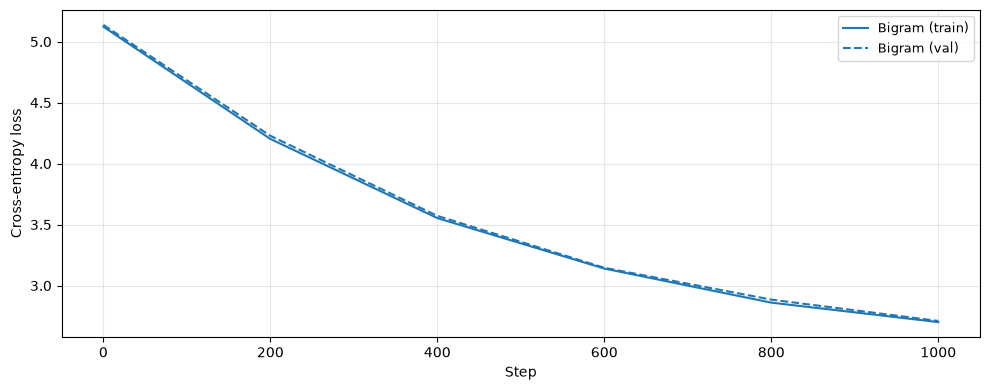

In [108]:
plot_losses(bigram_history, labels=["Bigram"])

In [109]:
print(generate(bigram_model, seed_text="DORINE\n", n_chars=300))

DORINE
PrX?BSp
Lé
Mleylcar ëé tGe1è−de..
P(sûIHaierjelsVòA ouxcu;ûr à−œu0][AmòfGYe
(I5òùFï voy1
Y f6)le
2S8sità06 drent :Bgoieracrfr uZGansunt îtezVooudé q;égçT9iGm6fez−teDindi;PrIgar CountrerDe'édonsprlaraienvoreneuPIiondNMouetdéndrt 7î'isoà mm.
Son qusà và ve,:aAromorsenageXIJue dô],(Bberélèlèbis l dx3ci


### Experiment 1: Temperature

The `temperature` parameter controls how "peaked" the distribution is at generation time.

- `temperature = 0.5` → overconfident, repetitive
- `temperature = 1.0` → standard sampling
- `temperature = 2.0` → very random

Try different values below:

In [110]:
seed = "DORANTE\n"
for temp in [0.5, 1.0, 2.0]:
    print(f"\n{'='*50}")
    print(f"temperature = {temp}")
    print('='*50)
    print(generate(bigram_model, seed, n_chars=200, temperature=temp))


temperature = 0.5
DORANTE
Couinqunnte vouten destitavour pouintt ce caitr den deSges houigen
Aha counteut de.
Sgere fouenus are el'ourent fantsourerereset deut direus pleXHant len deVinc Nont leur fir vourse
Moisie
Mor qus pou

temperature = 1.0
DORANTE
Aèdcu2ZGàleV9fan quit te1.
Jeò"I−toy derrPrtrâges;HuiÇHéd a?3Fâc,−a3Hibiretau loui3n dèçoux s 5uriCoRé:É"onçaselPR:ThezMai.
Lédyèns.
e depa sui,8F7œAhu? hioÉ? rsY3NJuntueaneu
GéZuileue,AtPâouM]É'itero

temperature = 2.0
DORANTE
Nr3fs"?mq1)2mcoÉîÉ2−rY"Pmecaçx8−co'uRMélF−ë10qOyg:(Eò4ÉVB;]qFÇ5°ç,)
Yséeé,doQn:.ìc,xpON?S−naœ[8'Ov−E! YoehutdOu2;9?çJdP°]lyZîÇ98uY!d8(I.l−c'o4emèie2o3fymëZZTrL?òc:1Jbepqféévœ6z°ïâ−Ro8TvFZòTut11
zbs"Où


---

## 4. Model 2: MLP

Bigrams only see one character at a time.

**Idea** (Bengio et al., 2003): look at a fixed-size window of the last `ctx` characters, embed each one, concatenate the embeddings, and pass them through an MLP.

**Key implementation trick**: `F.pad` + `unfold` creates all sliding windows in one go, without any Python loops.

In [111]:
class MLPModel(nn.Module):
    """
    Fixed-context MLP language model.

    For every position t, embeds the previous `ctx` characters,
    concatenates the embeddings, and passes them through a 2-layer MLP.

    Uses torch.Tensor.unfold for causal sliding windows (no Python loops).
    """
    def __init__(self, vocab_size, ctx=16, d_emb=32, d_hid=256):
        super().__init__()
        self.ctx = ctx
        self.emb = nn.Embedding(vocab_size, d_emb)
        self.net = nn.Sequential(
            nn.Linear(ctx * d_emb, d_hid),
            nn.GELU(),
            nn.Linear(d_hid, vocab_size),
        )

    def forward(self, x, y=None):
        B, T = x.shape
        # Left-pad with zeros so position 0 has context [0, 0, ..., x[0]]
        x_pad   = F.pad(x, (self.ctx - 1, 0), value=0)   # (B, T+ctx-1)
        windows = x_pad.unfold(1, self.ctx, 1)             # (B, T, ctx)
        e       = self.emb(windows)                        # (B, T, ctx, d_emb)
        logits  = self.net(e.view(B, T, -1))               # (B, T, vocab_size)
        loss    = None
        if y is not None:
            loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
        return logits, loss


MLP_CTX = 8   # kept deliberately small so attention's long-range advantage shows up
mlp_model = MLPModel(vocab_size, ctx=MLP_CTX, d_emb=32, d_hid=128)
n_params  = sum(p.numel() for p in mlp_model.parameters())
print(f"MLPModel: {n_params:,}")

MLPModel: 47,547


In [112]:
mlp_history = train_loop(mlp_model, n_steps=2000, lr=3e-3)

step     0/2000  |  train 4.529  val 4.529  |  0s
step   200/2000  |  train 1.805  val 1.915  |  1s
step   400/2000  |  train 1.642  val 1.780  |  1s
step   600/2000  |  train 1.575  val 1.732  |  2s
step   800/2000  |  train 1.547  val 1.686  |  2s
step  1000/2000  |  train 1.544  val 1.687  |  3s
step  1200/2000  |  train 1.507  val 1.673  |  4s
step  1400/2000  |  train 1.476  val 1.655  |  4s
step  1600/2000  |  train 1.489  val 1.625  |  5s
step  1800/2000  |  train 1.502  val 1.620  |  5s
step  2000/2000  |  train 1.448  val 1.667  |  6s


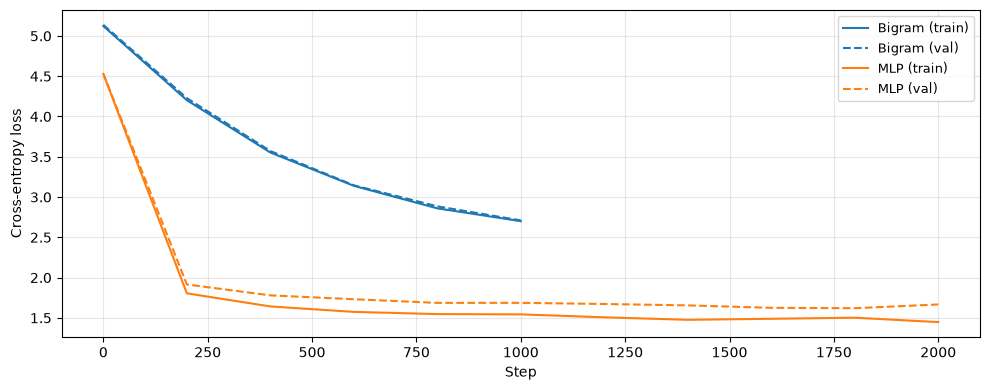

In [113]:
plot_losses(bigram_history, mlp_history, labels=["Bigram", "MLP"])

In [114]:
print(generate(mlp_model, seed_text="DORINE\n", n_chars=400))

DORINE
Vous êtes téglénés amourt vien ;  et volémaux assez ? 
Et sortendame, et Inguice qui pour est bout cavant qu'on
Gorgente, ce cette chasé dans me m'esterment avèce :  "
Sirpon
Ce qu'elle seclevous le saignâtre :  et voyons retés dout nomment danc et les ai pas la souverage, pour la, frère et nécriments on voir fauroit du ma temps innemante, Dans ma comme un faut avouer : .....
Espare, qu'aux perds 


### Experiment 2: Effect of context size

The `ctx` parameter controls how far back the MLP can look. Train two models: one with `ctx=4` and one with `ctx=16`, and compare them against the default `ctx=8`.

What do you expect to happen?
- A larger context should give lower loss (more information)
- But the input is `ctx × d_emb` dimensional, so larger context = larger model

In [115]:
# Uncomment and run (takes ~1 min on CPU)
# mlp_ctx4  = MLPModel(vocab_size, ctx=4,  d_emb=32, d_hid=128)
# mlp_ctx16 = MLPModel(vocab_size, ctx=16, d_emb=32, d_hid=128)
# h4   = train_loop(mlp_ctx4,  n_steps=2000)
# h16  = train_loop(mlp_ctx16, n_steps=2000)
# plot_losses(mlp_history, h4, h16, labels=["ctx=8 (default)", "ctx=4", "ctx=16"])

### Experiment 3: Deeper vs wider MLP

Modify `MLPModel` to use 3 layers instead of 2, or double `d_hid`. Does the extra capacity help?

*Hint*: replace `nn.Sequential(Linear(in, d_hid), GELU(), Linear(d_hid, V))` with a deeper variant.

In [116]:
# Uncomment, modify, and run:
# class MLPDeep(nn.Module):
#     def __init__(self, vocab_size, ctx=8, d_emb=32, d_hid=128):
#         super().__init__()
#         self.ctx = ctx
#         self.emb = nn.Embedding(vocab_size, d_emb)  # same as MLPModel
#         self.net = nn.Sequential(
#             nn.Linear(ctx * d_emb, d_hid), nn.GELU(),
#             nn.Linear(d_hid, d_hid),        nn.GELU(),
#             nn.Linear(d_hid, vocab_size),
#         )
#     # ... forward method same as MLPModel

---

## 5. Model 3: Single Self-Attention Head

With MLPs the context window is fixed. Token at position 3 always weighs position 1 the same, regardless of the actual content.

**Idea**: make the context *input-dependent*. Each token dynamically selects which past tokens to look at.

**Self-attention** computes, for each token, a *weighted sum* of past token values:

$$z_t = \sum_{s \le t} \alpha_{t,s} \cdot v_s \qquad \alpha_{t,s} = \text{softmax}\!\left(\frac{q_t \cdot k_s}{\sqrt{d_{\text{head}}}}\right)$$

where $q, k, v$ are learned linear projections of the input.

**Causal mask**: we forbid attending to future positions (masked with $-\infty$ before softmax).

In [117]:
class SingleHeadLM(nn.Module):
    """
    Language model with a single causal self-attention head.
    """
    def __init__(self, vocab_size, ctx=CONTEXT, d_model=256, head_dim=256):
        super().__init__()
        self.ctx      = ctx
        self.tok_emb  = nn.Embedding(vocab_size, d_model)
        self.pos_emb  = nn.Embedding(ctx, d_model)
        self.Q        = nn.Linear(d_model, head_dim, bias=False)
        self.K        = nn.Linear(d_model, head_dim, bias=False)
        self.V        = nn.Linear(d_model, head_dim, bias=False)
        self.proj     = nn.Linear(head_dim, vocab_size)
        self.scale    = head_dim ** -0.5
        # Causal mask: lower-triangular matrix (buffer moves with the model to device)
        self.register_buffer("mask", torch.tril(torch.ones(ctx, ctx)))

    def forward(self, x, y=None):
        B, T   = x.shape
        pos    = torch.arange(T, device=x.device)
        e      = self.tok_emb(x) + self.pos_emb(pos)               # (B, T, d_model)
        q, k, v = self.Q(e), self.K(e), self.V(e)                  # (B, T, head_dim)
        scores = (q @ k.transpose(-2, -1)) * self.scale             # (B, T, T)
        scores = scores.masked_fill(self.mask[:T, :T] == 0, float('-inf'))
        attn   = F.softmax(scores, dim=-1)                          # (B, T, T)
        out    = attn @ v                                            # (B, T, head_dim)
        logits = self.proj(out)                                      # (B, T, vocab_size)
        loss   = None
        if y is not None:
            loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
        return logits, loss

    @torch.no_grad()
    def get_attn_weights(self, x):
        """Return attention weights for visualisation."""
        pos    = torch.arange(x.shape[1], device=x.device)
        e      = self.tok_emb(x) + self.pos_emb(pos)
        q, k   = self.Q(e), self.K(e)
        scores = (q @ k.transpose(-2, -1)) * self.scale
        scores = scores.masked_fill(self.mask[:x.shape[1], :x.shape[1]] == 0, float('-inf'))
        return F.softmax(scores, dim=-1)   # (B, T, T)


attn_model = SingleHeadLM(vocab_size)
n_params   = sum(p.numel() for p in attn_model.parameters())
print(f"SingleHeadLM: {n_params:,}")

SingleHeadLM: 276,059


In [118]:
attn_history = train_loop(attn_model, n_steps=3000, lr=3e-3)

step     0/3000  |  train 4.532  val 4.530  |  0s
step   200/3000  |  train 2.325  val 2.353  |  2s
step   400/3000  |  train 2.268  val 2.301  |  4s
step   600/3000  |  train 2.238  val 2.287  |  6s
step   800/3000  |  train 2.208  val 2.273  |  7s
step  1000/3000  |  train 2.195  val 2.247  |  9s
step  1200/3000  |  train 2.193  val 2.236  |  11s
step  1400/3000  |  train 2.170  val 2.221  |  13s
step  1600/3000  |  train 2.182  val 2.221  |  15s
step  1800/3000  |  train 2.173  val 2.206  |  17s
step  2000/3000  |  train 2.158  val 2.218  |  19s
step  2200/3000  |  train 2.161  val 2.217  |  21s
step  2400/3000  |  train 2.160  val 2.221  |  23s
step  2600/3000  |  train 2.165  val 2.220  |  25s
step  2800/3000  |  train 2.174  val 2.218  |  27s
step  3000/3000  |  train 2.160  val 2.211  |  29s


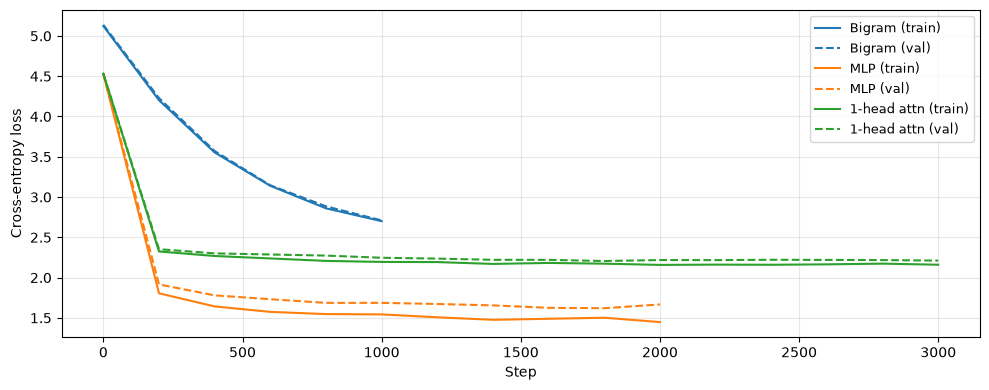

In [119]:
plot_losses(bigram_history, mlp_history, attn_history,
            labels=["Bigram", "MLP", "1-head attn"])

In [120]:
print(generate(attn_model, seed_text="DORINE\n", n_chars=400))

DORINE
Luc ot ci−croireglait lon ises Maîrre mame nont ie.
Masdi, ie ierle tentous fai somis mbeen que hass.
Al Licie quoi euc'aglaicempragnée à lantez, te mauvorinsen
An monéit eus irce forne en oficot voes oeuque quas fere ues
Vouri arte leut.
Acrotrillll'a sore ndende
Sursefi mi lous dit se cote
Vocerçon Te entitront non veucles es sensori voue−tuvr,
Et dolsite fra sotur mesre fafaime a dour
Que Mouss


### Visualising attention patterns

Let's look at what the attention head has learned to focus on.

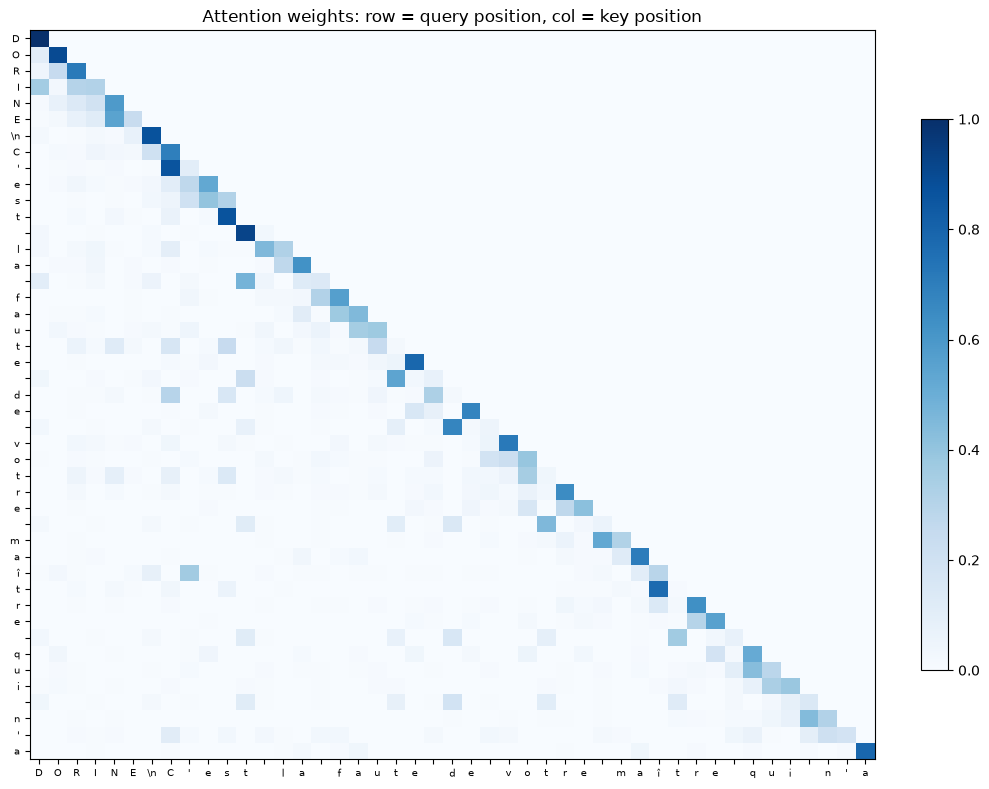


Note the triangular shape: each token only attends to itself and earlier tokens.


In [121]:
attn_model.eval()
snippet = "DORINE\nC'est la faute de votre maître qui n'a"
ids     = encode(snippet)
x_vis   = torch.tensor([ids], dtype=torch.long, device=device)
weights = attn_model.get_attn_weights(x_vis)[0].cpu().numpy()  # (T, T)

T   = len(ids)
fig, ax = plt.subplots(figsize=(10, 8))
im  = ax.imshow(weights, aspect="auto", cmap="Blues", origin="upper",
                vmin=0, vmax=weights.max())
ax.set_xticks(range(T))
ax.set_yticks(range(T))
ax.set_xticklabels([repr(c)[1:-1] for c in snippet], fontsize=7)
ax.set_yticklabels([repr(c)[1:-1] for c in snippet], fontsize=7)
ax.set_title("Attention weights: row = query position, col = key position")
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()
print("\nNote the triangular shape: each token only attends to itself and earlier tokens.")

### Experiment 4: Removing the causal mask

What happens if the model can "see into the future"? Modify `SingleHeadLM.forward` to skip the `masked_fill` line and train again.

This would be invalid for generation (you can't see future tokens at test time), but demonstrates why the mask matters during training.

In [122]:
# Uncomment and try:
# class SingleHeadNoCausal(SingleHeadLM):
#     def forward(self, x, y=None):
#         B, T   = x.shape
#         pos    = torch.arange(T, device=x.device)
#         e      = self.tok_emb(x) + self.pos_emb(pos)
#         q, k, v = self.Q(e), self.K(e), self.V(e)
#         scores = (q @ k.transpose(-2, -1)) * self.scale
#         # No mask: the model can see the future!
#         attn   = F.softmax(scores, dim=-1)
#         out    = attn @ v
#         logits = self.proj(out)
#         loss   = None
#         if y is not None:
#             loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
#         return logits, loss
#
# no_causal = SingleHeadNoCausal(vocab_size)
# h_nc = train_loop(no_causal, n_steps=2000)
# plot_losses(attn_history, h_nc, labels=["Causal", "No mask (cheating)"])
# # Does the loss drop? Try generating from no_causal. What do you observe?

### Experiment 5: Head dimension

Try `head_dim=16` vs `head_dim=128`. The head dimension controls the capacity of the key/query/value projections.

What's the parameter count in each case? Does the loss improve?

In [123]:
# for head_dim in [16, 64, 128]:
#     m = SingleHeadLM(vocab_size, head_dim=head_dim)
#     n = sum(p.numel() for p in m.parameters())
#     print(f"head_dim={head_dim:3d}  →  {n:,} params")

---

## 6. Model 4: Transformer Block

A real Transformer block adds three ingredients to bare attention:

| Component | Why |
|-----------|-----|
| **Multi-head attention** | Multiple attention patterns in parallel |
| **Feed-forward MLP** | Per-token non-linear computation after attention |
| **Residual connections** | Gradients flow without degradation through depth |
| **LayerNorm** | Stable activations at each sub-layer |

This is the *pre-norm* variant (norm before the sub-layer), which is more stable for training.

In [124]:
class MultiHeadAttention(nn.Module):
    """
    Multi-head causal self-attention.
    Runs n_heads attention heads in parallel, then projects their concatenated outputs.
    """
    def __init__(self, d_model, n_heads, ctx):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_heads  = n_heads
        self.head_dim = d_model // n_heads
        # Project to Q, K, V in one shot for efficiency
        self.qkv      = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj     = nn.Linear(d_model, d_model,     bias=False)
        self.scale    = self.head_dim ** -0.5
        self.register_buffer("mask", torch.tril(torch.ones(ctx, ctx)))

    def forward(self, x):
        B, T, C = x.shape
        # Split into Q, K, V and reshape into n_heads heads
        q, k, v = self.qkv(x).split(C, dim=-1)             # each: (B, T, C)
        def reshape(t):
            return t.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        q, k, v = reshape(q), reshape(k), reshape(v)         # (B, H, T, head_dim)
        # Scaled dot-product attention for all heads at once
        scores = (q @ k.transpose(-2, -1)) * self.scale      # (B, H, T, T)
        scores = scores.masked_fill(self.mask[:T, :T] == 0, float('-inf'))
        attn   = F.softmax(scores, dim=-1)                   # (B, H, T, T)
        out    = (attn @ v)                                   # (B, H, T, head_dim)
        # Merge heads and project
        out    = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(out)


class TransformerBlock(nn.Module):
    """
    One Transformer block: pre-norm, multi-head attention, FFN, residuals.
    Signature: (B, T, d_model) → (B, T, d_model)
    """
    def __init__(self, d_model, n_heads, d_ff, ctx):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, ctx)
        self.ln2  = nn.LayerNorm(d_model)
        self.mlp  = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))   # attention sub-layer with residual
        x = x + self.mlp(self.ln2(x))    # FFN sub-layer with residual
        return x

In [125]:
class BlockLM(nn.Module):
    """Language model with a single Transformer block."""
    def __init__(self, vocab_size, ctx=CONTEXT, d_model=128, n_heads=4, d_ff=1024):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(ctx, d_model)
        self.block   = TransformerBlock(d_model, n_heads, d_ff, ctx)
        self.ln    = nn.LayerNorm(d_model)
        self.head  = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, x, y=None):
        B, T = x.shape
        pos  = torch.arange(T, device=x.device)
        h    = self.tok_emb(x) + self.pos_emb(pos)
        h    = self.block(h)
        logits = self.head(self.ln(h))
        loss   = None
        if y is not None:
            loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
        return logits, loss


block_model = BlockLM(vocab_size)
n_params    = sum(p.numel() for p in block_model.parameters())
print(f"BlockLM: {n_params:,}")

BlockLM: 369,280


In [126]:
block_history = train_loop(block_model, n_steps=3000, lr=3e-3)

step     0/3000  |  train 4.714  val 4.712  |  0s
step   200/3000  |  train 2.000  val 2.059  |  4s
step   400/3000  |  train 1.665  val 1.775  |  8s
step   600/3000  |  train 1.465  val 1.671  |  12s
step   800/3000  |  train 1.433  val 1.589  |  15s
step  1000/3000  |  train 1.368  val 1.548  |  19s
step  1200/3000  |  train 1.346  val 1.539  |  23s
step  1400/3000  |  train 1.324  val 1.523  |  27s
step  1600/3000  |  train 1.336  val 1.504  |  31s
step  1800/3000  |  train 1.304  val 1.485  |  35s
step  2000/3000  |  train 1.282  val 1.521  |  39s
step  2200/3000  |  train 1.274  val 1.495  |  43s
step  2400/3000  |  train 1.286  val 1.481  |  46s
step  2600/3000  |  train 1.248  val 1.494  |  50s
step  2800/3000  |  train 1.264  val 1.481  |  54s
step  3000/3000  |  train 1.258  val 1.506  |  58s


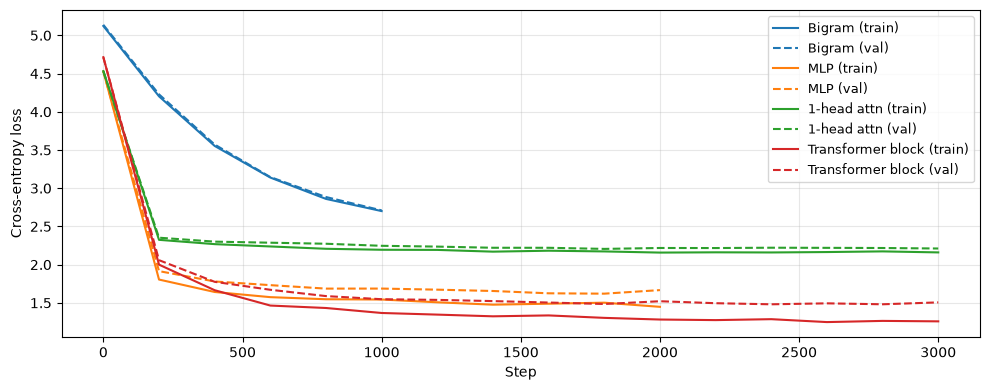

In [127]:
plot_losses(bigram_history, mlp_history, attn_history, block_history,
            labels=["Bigram", "MLP", "1-head attn", "Transformer block"])

In [128]:
print(generate(block_model, seed_text="DORINE\n", n_chars=400))

DORINE
Cette d'autant de muse ardeur Cévrez drôle, comme elle détemps qu'il nove
Le turment. Cachette ! 
Hé !  tous
Comment ? 
Lucile
Peut−ôtume qu'on ferez lancher tous prince qu'il l'amuse : 
Ne telle, de te jamais d'être de fati surmonspe pour noire à Célie.
Alcmène
Quoi ?  voilez−vous mourage :  c'étate hymp, Morêtez−vous que de
lange parti se mélange.
Scapin
J'en ai qu'il sort gentilhomme, et ne
con


### Experiment 6: Number of heads

Multi-head attention runs multiple attention patterns in parallel. Try `n_heads = 1` vs `n_heads = 8`. Both have the same total `d_model`, so the number of parameters stays the same.

What changes? Each head has a smaller `head_dim = d_model // n_heads`.

In [129]:
# for n_heads in [1, 2, 4, 8]:
#     m = BlockLM(vocab_size, n_heads=n_heads)
#     h = train_loop(m, n_steps=2000)
#     # save h and compare

### Experiment 7: Ablating the residual connections

The residual connections (`x = x + sub_layer(x)`) are crucial for deep networks. What happens if you remove them?

Modify `TransformerBlock.forward`:
```python
# Without residuals:
x = self.attn(self.ln1(x))
x = self.mlp(self.ln2(x))
```

In [130]:
# class TransformerBlockNoResidual(nn.Module):
#     def __init__(self, d_model, n_heads, d_ff, ctx):
#         super().__init__()
#         self.ln1  = nn.LayerNorm(d_model)
#         self.attn = MultiHeadAttention(d_model, n_heads, ctx)
#         self.ln2  = nn.LayerNorm(d_model)
#         self.mlp  = nn.Sequential(
#             nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model))
#
#     def forward(self, x):
#         x = self.attn(self.ln1(x))   # no +x
#         x = self.mlp(self.ln2(x))    # no +x
#         return x
#
# # Build a BlockLM that uses TransformerBlockNoResidual instead
# # and compare the training curves

---

## 7. Model 5: MiniGPT

We now **stack** multiple Transformer blocks to build a full GPT-style decoder.

Two key additions vs the single block:

1. **Stacked blocks**: $N$ Transformer blocks in series. Each block refines the representations from the previous one, allowing the model to build hierarchical, compositional features.

2. **Weight tying**: the output projection and the input token embedding share weights. This was used in the original GPT and GPT-2, and often improves perplexity.

In [131]:
class MiniGPT(nn.Module):
    """
    GPT-style decoder Transformer.

    Token embedding + positional embedding → N Transformer blocks →
    LayerNorm → linear head (tied to token embedding weights).
    """
    def __init__(self, vocab_size, ctx=CONTEXT, d_model=128, n_heads=4,
                 n_layers=4, d_ff=512):
        super().__init__()
        self.ctx     = ctx
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(ctx, d_model)
        self.blocks  = nn.Sequential(
            *[TransformerBlock(d_model, n_heads, d_ff, ctx) for _ in range(n_layers)]
        )
        self.ln      = nn.LayerNorm(d_model)
        self.head    = nn.Linear(d_model, vocab_size, bias=False)
        # Weight tying: share token embedding and output weights
        self.tok_emb.weight = self.head.weight

    def forward(self, x, y=None):
        B, T      = x.shape
        positions = torch.arange(T, device=x.device)
        h         = self.tok_emb(x) + self.pos_emb(positions)   # (B, T, d_model)
        h         = self.blocks(h)                               # (B, T, d_model)
        logits    = self.head(self.ln(h))                        # (B, T, vocab_size)
        loss      = None
        if y is not None:
            loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
        return logits, loss

### Parameter count comparison

In [132]:
models_info = [
    ("Bigram",             BigramModel(vocab_size)),
    ("MLP",                MLPModel(vocab_size, ctx=MLP_CTX, d_hid=128)),
    ("Single-head attn",   SingleHeadLM(vocab_size)),
    ("Transformer block",  BlockLM(vocab_size)),
    ("MiniGPT",            MiniGPT(vocab_size)),
]

print(f"{'Model':<22}  {'Parameters':>12}")
print("-" * 36)
for name, m in models_info:
    n = sum(p.numel() for p in m.parameters())
    print(f"{name:<22}  {n:>12,}")

Model                     Parameters
------------------------------------
Bigram                         8,281
MLP                           92,091
Single-head attn             276,059
Transformer block            369,280
MiniGPT                      819,328


### Training MiniGPT

This is the biggest model. Training takes roughly:
- **MPS** (Apple Silicon): ~4–5 minutes
- **CUDA** (GPU): ~1–2 minutes
- **CPU**: ~15–20 minutes (consider reducing to 3000 steps if too slow)

The cell prints a progress line every 200 steps so you can follow along.

In [133]:
gpt_model   = MiniGPT(vocab_size)
# Cosine LR decay: start at 3e-3, decay to 1e-4 over 5000 steps
gpt_history = train_loop(gpt_model, n_steps=5000, lr=3e-3, cosine_decay=True)

step     0/5000  |  train 4.664  val 4.668  |  0s
step   200/5000  |  train 2.646  val 2.653  |  12s
step   400/5000  |  train 2.493  val 2.516  |  22s
step   600/5000  |  train 2.390  val 2.433  |  33s
step   800/5000  |  train 2.265  val 2.275  |  44s
step  1000/5000  |  train 1.972  val 2.041  |  54s
step  1200/5000  |  train 1.740  val 1.858  |  65s
step  1400/5000  |  train 1.667  val 1.779  |  75s
step  1600/5000  |  train 1.546  val 1.712  |  86s
step  1800/5000  |  train 1.522  val 1.623  |  97s
step  2000/5000  |  train 1.458  val 1.586  |  107s
step  2200/5000  |  train 1.414  val 1.615  |  118s
step  2400/5000  |  train 1.393  val 1.552  |  128s
step  2600/5000  |  train 1.351  val 1.559  |  139s
step  2800/5000  |  train 1.314  val 1.501  |  149s
step  3000/5000  |  train 1.306  val 1.502  |  160s
step  3200/5000  |  train 1.302  val 1.502  |  171s
step  3400/5000  |  train 1.283  val 1.445  |  181s
step  3600/5000  |  train 1.279  val 1.475  |  192s
step  3800/5000  |  tra

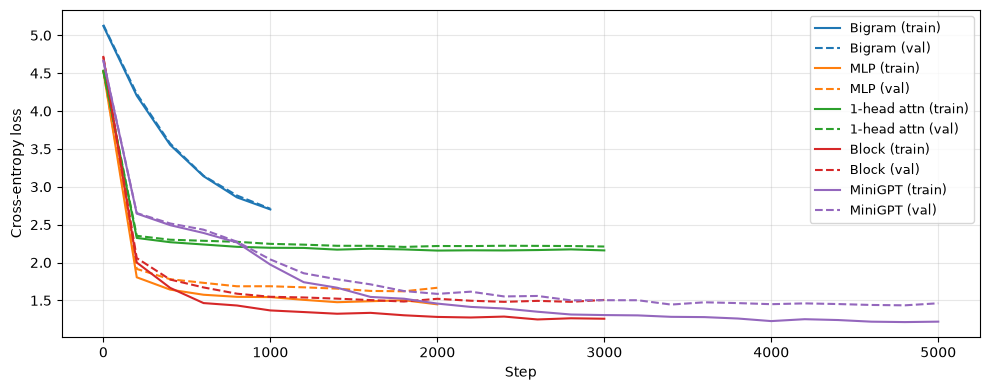

In [134]:
plot_losses(bigram_history, mlp_history, attn_history, block_history, gpt_history,
            labels=["Bigram", "MLP", "1-head attn", "Block", "MiniGPT"])

In [135]:
# Generate with top-k sampling to get more coherent text
print("=== Top-k=10, temperature=0.8 ===")
print(generate(gpt_model, seed_text="ORGON\n", n_chars=500,
               temperature=0.8, top_k=10))

=== Top-k=10, temperature=0.8 ===
ORGON
Jélie
Petite suivience que de nous avec mite : 
Le m'en venu dit.
Acaste
Non.
Madame, arme Madame, je vois que puissant plus que je ne m'en entend
Que m'arrutier aussi prendre de la croision ;  et par le dire comme il faut au comédience, cela secret
tour ce qu'à vous venir s'en peut plus demeuré, et le dis comptent le porte ;  et je demande tout le couche à
rarrêt avec coupeal, et ce que ces grands de vous ressens, pour vouloir s'utront de la caise ;  et ce qu'il
n'en obstinuir les mots caractèr


### Experiment 8: Depth vs width

Keep the total parameter budget roughly constant and compare a *deep* model (more layers, small `d_model`) vs a *wide* model (fewer layers, larger `d_model`).

For example:
- **Deep**: `n_layers=8, d_model=64, d_ff=128`
- **Wide**: `n_layers=2, d_model=128, d_ff=512`

In [136]:
# deep = MiniGPT(vocab_size, d_model=64,  n_heads=4, n_layers=8, d_ff=256)  # ~412K params
# wide = MiniGPT(vocab_size, d_model=128, n_heads=4, n_layers=2, d_ff=512)  # ~424K params
# for name, m in [("deep", deep), ("wide", wide)]:
#     n = sum(p.numel() for p in m.parameters())
#     print(f"{name}: {n:,} params")  # should be roughly equal
# h_deep = train_loop(deep, n_steps=3000)
# h_wide = train_loop(wide, n_steps=3000)
# plot_losses(gpt_history, h_deep, h_wide, labels=["Baseline", "Deep", "Wide"])

### Experiment 9: Context length

The context length `CONTEXT` controls how far back the model can look. Larger context → more memory and compute (attention is O(T²)), but potentially lower loss.

Try `CONTEXT=64` vs `CONTEXT=256`.

*Note*: you'll need to re-run all the cells from `get_batch` onwards since `CONTEXT` is used throughout.

In [137]:
# CONTEXT = 256    # ← change this and re-run from the get_batch cell
# gpt_long = MiniGPT(vocab_size, ctx=CONTEXT)
# h_long   = train_loop(gpt_long, n_steps=3000)

### Experiment 10: Top-k sampling strategies

Compare generating with different values of `top_k`:
- `top_k=None` → pure temperature sampling (all tokens eligible)
- `top_k=5` → only the 5 most likely tokens
- `top_k=50` → wider distribution

In [138]:
seed = "TARTUFFE\n"
for k in [None, 5, 20, 50]:
    label = f"top_k={k}"
    print(f"\n{'─'*50}  {label}")
    print(generate(gpt_model, seed, n_chars=200, temperature=1.0, top_k=k))


──────────────────────────────────────────────────  top_k=None
TARTUFFE
Lélie, Célimène est−il point un enferdre, une fourné fait. Ah !  Quidos à tendres, je ne vous assez pour l'Il suffite ma les
un animé. Je vous étiez dans un éclat ;  et ne pont pas étonné de bâtie une

──────────────────────────────────────────────────  top_k=5
TARTUFFE
Monsieur des voir l'esprit que vous vous a liberté, et je vous assez pour là.
Arnolphe
Ma feront de tenir. Vous−nous dans mon maître, et de moi d'avoir d'un, nous deux discus ;  et je vons, si je sais

──────────────────────────────────────────────────  top_k=20
TARTUFFE
Mon Dieu !  c'est votre confidence, ce lieu est du rôle : 
Vous aime est un trop des rêmes paroles, et ce que tu attendez cette sage, et qui parle petit à l'abaisser.
L'obtmué, et il n'est pas qu'il y

──────────────────────────────────────────────────  top_k=50
TARTUFFE
Maître JacquesIt Sûffer ? 
Et de grâces, pour divinité : 
Si votre père, par tout cette bon et pré moi le doucem

---

## 8. Final Comparison

Let's summarise what each model learned.

In [139]:
# Final validation loss for each model
all_models = [
    ("Bigram",      bigram_model, bigram_history),
    ("MLP",         mlp_model,   mlp_history),
    ("1-head attn", attn_model,  attn_history),
    ("Block",       block_model, block_history),
    ("MiniGPT",     gpt_model,   gpt_history),
]

print(f"{'Model':<18}  {'Final val loss':>14}  {'Random baseline':>15}")
print("-" * 50)
for name, _, h in all_models:
    val_loss = h[-1]["val"]
    print(f"{name:<18}  {val_loss:>14.3f}  {random_loss:>15.3f}")

Model               Final val loss  Random baseline
--------------------------------------------------
Bigram                       2.710            4.511
MLP                          1.667            4.511
1-head attn                  2.211            4.511
Block                        1.506            4.511
MiniGPT                      1.462            4.511


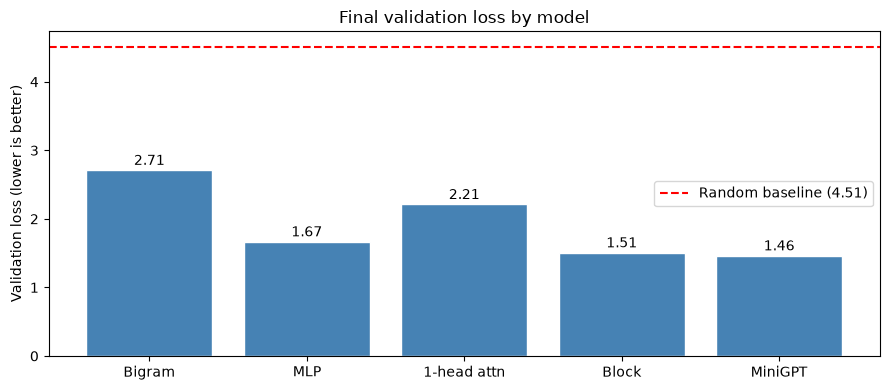

In [140]:
# Bar chart of final validation loss
names = [m[0] for m in all_models]
vals  = [m[2][-1]["val"] for m in all_models]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(names, vals, color="steelblue", edgecolor="white")
ax.axhline(random_loss, color="red", linestyle="--", label=f"Random baseline ({random_loss:.2f})")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f"{v:.2f}", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Validation loss (lower is better)")
ax.set_title("Final validation loss by model")
ax.legend()
plt.tight_layout()
plt.show()

In [141]:
# All models generate the same seed. Spot the differences!
seed = "DORINE\nIl ne faut pas "
print(f"Seed: {seed!r}\n")

for name, model, _ in all_models:
    print(f"{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(generate(model, seed, n_chars=250, temperature=0.9, top_k=20))
    print()

Seed: 'DORINE\nIl ne faut pas '

  Bigram
DORINE
Il ne faut pas aiende.
Oueilà−tontentre dinur
Pr ? phémouer
Qdie,ntrin, ceront prelur.Lavœ
Je
CJ'avo"ViÇèn ponts doun bl−mue prez, prihHar ditoie,
Maont
Dedittiro8re
Laitostt  es lsèz−vosèsts rdourr.
Sce a pois dr,
Sggu'iey ttenuse qu el'At deue,
Resent,
Padr arden

  MLP
DORINE
Il ne faut pas aucune tier de vous m'en seul nous secores, et me moeux aurons accessaire de s'écleté et de mon âmeurs de souvillire ?  Je beau tir les dépressend out en fatout le mointe,
Et ce tré sans censeinur monde se dans parler la saus on parlonne
Ma foi, cet 

  1-head attn
DORINE
Il ne faut pas tesui mouri
Ahgecradil rer lviez−minnez− poir llens dez voutt qu'il
Je pe ant douvre loudez−ui phoirse
Cele ves
cemen ta bela romes far ceute de me n'exi eus eux phoun ame faitsame l'augre leut lauveus il, que meu cous fit mende ; 
Et d'coine pau jon

  Block
DORINE
Il ne faut pas encontre courtis bien. Voilà qui parler.
Clitidas
Chansons...
Amphitryon
De gonger un 